In [2]:
# Download
print("Downloading 9GB Flickr dataset...")
!kaggle datasets download -d hsankesara/flickr-image-dataset --force

# Unzip
print("Unzipping... this takes a moment.")
!mkdir -p /content/flickr30k
!unzip -q flickr-image-dataset.zip -d /content/flickr30k
!rm flickr-image-dataset.zip

print("SUCCESS! Data is ready in /content/flickr30k")

Dataset URL: https://www.kaggle.com/datasets/hsankesara/flickr-image-dataset
License(s): CC0-1.0
100% 8.16G/8.16G [00:45<00:00, 191MB/s]

Unzipping... this takes a moment.
🚀 SUCCESS! Data is ready in /content/flickr30k


In [5]:
!pip install "protobuf<6.0.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.5/320.5 kB 11.3 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 7.34.0
    Uninstalling protobuf-7.34.0:
      Successfully uninstalled protobuf-7.34.0


In [12]:
import pickle
import numpy as np
import pandas as pd
from tqdm import tqdm
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Model

# Load_data
df = pd.read_csv('/content/flickr30k/flickr30k_images/results.csv', sep='|')
df.columns = [c.strip() for c in df.columns]
all_images = df['image_name'].unique()

# Load_Model
base_model = InceptionV3(weights='imagenet')
encoder_model = Model(base_model.input, base_model.layers[-2].output)

def get_features(image_name):
    path = f"/content/flickr30k/flickr30k_images/flickr30k_images/{image_name}"
    img = load_img(path, target_size=(299, 299))
    x = img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    features = encoder_model.predict(x, verbose=0)
    return features.flatten()

# 60%_dataset_used
features_dict = {}
for img in tqdm(all_images[:18000]):
    f = get_features(img)
    if f is not None:
        features_dict[img] = f

# Save_locally
with open("features.pkl", "wb") as f:
    pickle.dump(features_dict, f)

# Save_filtered_captions
df_filtered = df[df['image_name'].isin(features_dict.keys())]
df_filtered.to_csv("cleaned_captions.csv", index=False)
print(f"Features extracted for 18000 images")

100%|██████████| 18000/18000 [32:10<00:00,  9.32it/s]


Features extracted for 18000 images


In [21]:
import pandas as pd
import numpy as np
import pickle
import re
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, add, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint

# Drive_&_Path_Setup
drive_path = '/content/drive/MyDrive/ImageCaptioningProject'
if not os.path.exists(drive_path): os.makedirs(drive_path)

# Load_Filter_Dataset
with open("features.pkl", "rb") as f:
    features_dict = pickle.load(f)

df = pd.read_csv("cleaned_captions.csv")
df['image_name'] = df['image_name'].astype(str)
df = df[df['image_name'].isin(features_dict.keys())].reset_index(drop=True)

# Text_Preprocessing
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z ]', '', text)
    return f"startseq {text.strip()} endseq"

df['comment'] = df['comment'].apply(clean_text)
vocab = sorted(set(" ".join(df['comment']).split()))
vocab_size = len(vocab) + 1
word_to_idx = {word: i+1 for i, word in enumerate(vocab)}
idx_to_word = {i+1: word for i, word in enumerate(vocab)}
max_length = max(len(c.split()) for c in df['comment'])

# Save_mappings_to_Drive
with open(f"{drive_path}/word_to_idx.pkl", "wb") as f:
    pickle.dump(word_to_idx, f)
with open(f"{drive_path}/idx_to_word.pkl", "wb") as f:
    pickle.dump(idx_to_word, f)

# Final_Model(LSTM + Batch Normalization)
inputs1 = Input(shape=(2048,))
fe1 = Dropout(0.5)(inputs1)
fe2 = Dense(512, activation='relu')(fe1)
fe3 = BatchNormalization()(fe2)

inputs2 = Input(shape=(max_length,))
se1 = Embedding(vocab_size, 512, mask_zero=False)(inputs2)
se2 = Dropout(0.5)(se1)
se3 = LSTM(512)(se2)

decoder1 = add([fe3, se3])
decoder2 = Dense(512, activation='relu')(decoder1)
outputs = Dense(vocab_size, activation='softmax')(decoder2)

model = Model(inputs=[inputs1, inputs2], outputs=outputs)
model.compile(loss='categorical_crossentropy', optimizer='adam')

# Data_Generator
def data_generator(df, features, word_to_idx, max_length, vocab_size, batch_size):
    X1, X2, y = [], [], []
    while True:
        # Shuffle_internally
        df = df.sample(frac=1).reset_index(drop=True)
        for i in range(len(df)):
            row = df.iloc[i]
            feature = features.get(row['image_name'])
            if feature is None: continue

            seq = [word_to_idx[w] for w in row['comment'].split() if w in word_to_idx]
            for j in range(1, len(seq)):
                in_seq, out_seq = seq[:j], seq[j]
                in_seq = pad_sequences([in_seq], maxlen=max_length, padding='pre')[0]
                out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]
                X1.append(feature)
                X2.append(in_seq)
                y.append(out_seq)

            if len(X1) >= batch_size:
                yield ((np.array(X1[:batch_size]), np.array(X2[:batch_size])), np.array(y[:batch_size]))
                X1, X2, y = [], [], []

checkpoint = ModelCheckpoint(f"{drive_path}/best_model.keras", monitor='loss', save_best_only=True, verbose=1)
lr_scheduler = ReduceLROnPlateau(monitor='loss', factor=0.5, patience=2, verbose=1)

train_dataset = tf.data.Dataset.from_generator(
    lambda: data_generator(df, features_dict, word_to_idx, max_length, vocab_size, 64),
    output_signature=((tf.TensorSpec(shape=(None, 2048), dtype=tf.float32),
                       tf.TensorSpec(shape=(None, max_length), dtype=tf.int32)),
                      tf.TensorSpec(shape=(None, vocab_size), dtype=tf.float32))
).prefetch(tf.data.AUTOTUNE)

print(f"Starting training.")
model.fit(train_dataset, epochs=20, steps_per_epoch=len(df)//64, verbose=1, callbacks=[checkpoint, lr_scheduler])

model.save(f"{drive_path}/final_model_improved.keras")

Starting training.
Epoch 1/20
1405/1406 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 5.4629
Epoch 1: loss improved from inf to 4.98759, saving model to /content/drive/MyDrive/ImageCaptioningProject/best_model.keras
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 68s 47ms/step - loss: 5.4622 - learning_rate: 0.0010
Epoch 2/20
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 4.4935
Epoch 2: loss improved from 4.98759 to 4.43765, saving model to /content/drive/MyDrive/ImageCaptioningProject/best_model.keras
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 63s 45ms/step - loss: 4.4935 - learning_rate: 0.0010
Epoch 3/20
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 4.3169
Epoch 3: loss improved from 4.43765 to 4.25501, saving model to /content/drive/MyDrive/ImageCaptioningProject/best_model.keras
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 62s 44ms/step - loss: 4.3169 - learning_rate: 0.0010
Epoch 4/20
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 4.1374
Epoch 4: loss improved from 4.25501 to 4.12079, saving model to /content


--- Final Evaluation Results ---


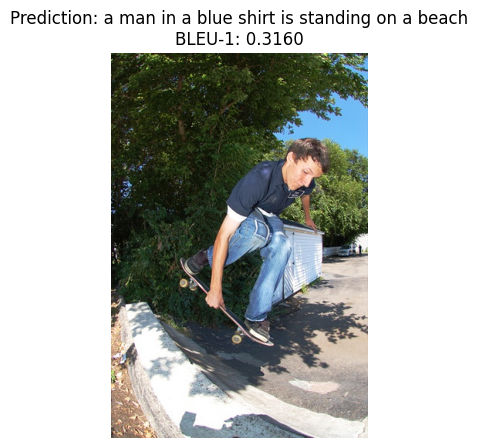

SAMPLE 1:
  > Ground Truth: the guy in the blue shirt and jeans performs a grab trick on his skateboard
  > Model Prediction: a man in a blue shirt is standing on a beach
  > BLEU-1 Score: 0.3160
--------------------------------------------------


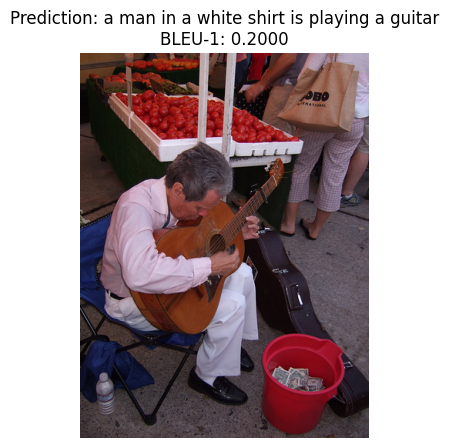

SAMPLE 2:
  > Ground Truth: a guitarist busks beside a vegetable stand
  > Model Prediction: a man in a white shirt is playing a guitar
  > BLEU-1 Score: 0.2000
--------------------------------------------------


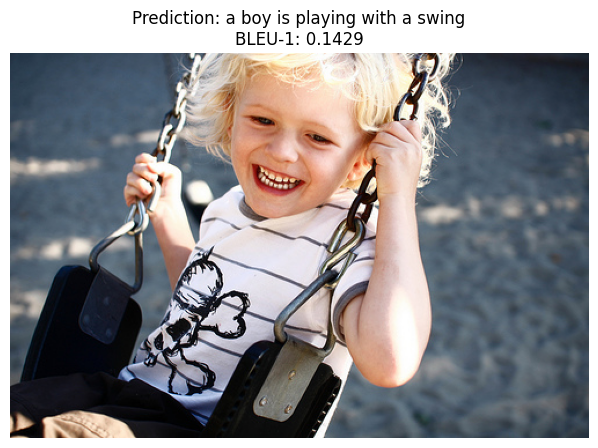

SAMPLE 3:
  > Ground Truth: the blondhaired child played on the swing
  > Model Prediction: a boy is playing with a swing
  > BLEU-1 Score: 0.1429
--------------------------------------------------


In [24]:
import matplotlib.pyplot as plt
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img

# Load_BestModel
model = load_model(f"{drive_path}/best_model.keras")
with open(f"{drive_path}/word_to_idx.pkl", "rb") as f:
    word_to_idx = pickle.load(f)
with open(f"{drive_path}/idx_to_word.pkl", "rb") as f:
    idx_to_word = pickle.load(f)

# Corrected_Prediction(pre padding)
def predict_caption(photo_feature, max_length=max_length):
    in_text = 'startseq'
    for i in range(max_length):
        sequence = [word_to_idx.get(w) for w in in_text.split() if word_to_idx.get(w)]
        sequence = pad_sequences([sequence], maxlen=max_length, padding='pre')

        yhat = model.predict([photo_feature.reshape(1, 2048), sequence], verbose=0)
        word = idx_to_word.get(np.argmax(yhat))

        if word is None or word == 'endseq': break
        in_text += ' ' + word
    return in_text.replace('startseq ', '')

# Generate_3_Results
print("\n--- Final Evaluation Results ---")
for i in range(3):
    sample = df.sample(1).iloc[0]
    img_name = sample['image_name']
    photo = features_dict[img_name]

    # Generate_modelprediction
    pred = predict_caption(photo)

    # Cleanup_groundtruth
    raw_ground_truth = sample['comment'].replace('startseq ', '').replace(' endseq', '')
    ref = [raw_ground_truth.split()]

    # Calculate_BLEU-1_Score
    score = sentence_bleu(ref, pred.split(), weights=(1, 0, 0, 0), smoothing_function=SmoothingFunction().method1)

    # Plotting
    plt.figure(figsize=(8, 5))
    img_full_path = f"/content/flickr30k/flickr30k_images/flickr30k_images/{img_name}"
    plt.imshow(load_img(img_full_path))
    plt.title(f"Prediction: {pred}\nBLEU-1: {score:.4f}")
    plt.axis('off')
    plt.show()

    # Printed_output
    print(f"SAMPLE {i+1}:")
    print(f"  > Ground Truth: {raw_ground_truth}")
    print(f"  > Model Prediction: {pred}")
    print(f"  > BLEU-1 Score: {score:.4f}")
    print("-" * 50)